# Monte Carlo VaR

Historical simulation can only re-play scenarios that *actually occurred* in the 6-year window. Parametric Normal VaR computes a closed-form number but the Q–Q + Jarque–Bera diagnostic in notebook 03 shows the Normality assumption is badly violated (excess kurtosis +11.6, JB p-value ≈ 0).

Monte Carlo sits between these two methods. It draws 10,000 hypothetical daily returns from a *modelled* multivariate distribution that is calibrated to the historical covariance structure (preserving asset correlations via Cholesky decomposition) but unconstrained by which days actually happened. The result is a VaR estimate that can sample tail scenarios beyond the empirical window — provided the underlying distributional model is appropriate.

This notebook also addresses the natural follow-up question: **how many simulation paths is enough?** The convergence check at the end re-runs MC at 1k / 5k / 10k / 50k paths to show how the 99% VaR estimate stabilises.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Constants --------------------------------------------------------
SEED            = 42            # reproducibility — every MC result below is deterministic given this seed
N_SIMULATIONS   = 10_000
PORTFOLIO_VALUE = 1_000_000
TRADING_DAYS    = 252
FIG_DIR         = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# --- Load -------------------------------------------------------------
log_returns       = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv("../data/portfolio_returns.csv", index_col=0, parse_dates=True).squeeze()

n_assets = log_returns.shape[1]
weights  = np.full(n_assets, 1 / n_assets)
assert abs(weights.sum() - 1.0) < 1e-9

print(f"{n_assets} assets, equal weights = {weights[0]:.4f} each")
print(f"{len(log_returns)} daily observations")

8 assets, equal weights = 0.1250 each
1508 daily observations


## Cholesky decomposition

The naive approach — generate uncorrelated standard-normal returns for each asset independently — would *destroy* the correlation structure. SPY and AAPL would no longer move together, GLD would no longer offer diversification, and the resulting portfolio variance would be wildly understated.

Cholesky decomposition fixes this. For a positive-definite covariance matrix Σ, Cholesky produces a lower-triangular matrix L such that L · Lᵀ = Σ. Sampling Z ~ N(0, I) and computing L · Z gives correlated draws with covariance Σ exactly.

This is the single most important piece of mathematics in the notebook — implementing it wrongly is the #1 Monte Carlo bug.

We compute Cholesky on the *daily* covariance (not annualised) because we're simulating one-day horizon VaR.

In [2]:
cov_daily = log_returns.cov()                  # daily covariance, not annualised
L = np.linalg.cholesky(cov_daily.values)        # lower-triangular Cholesky factor

# Verify L @ L.T reconstructs the covariance matrix
reconstruction_error = np.abs(L @ L.T - cov_daily.values).max()
print(f"Max |L Lᵀ - Σ|: {reconstruction_error:.2e}   (should be ~1e-16)")
print(f"L shape: {L.shape}")

Max |L Lᵀ - Σ|: 2.71e-20   (should be ~1e-16)
L shape: (8, 8)


## Run the simulation

Set the RNG seed, draw 10,000 × 8 independent N(0,1) samples, transform with L to get correlated returns, add the per-asset drift, and project onto the equal-weight portfolio.

In [3]:
np.random.seed(SEED)

# Step 1: independent standard-normal draws
Z = np.random.standard_normal((N_SIMULATIONS, n_assets))

# Step 2: correlate via Cholesky (equivalent to Z @ L.T)
correlated_shocks = Z @ L.T

# Step 3: add drift (per-asset mean daily return)
daily_mean = log_returns.mean().values
simulated_asset_returns = correlated_shocks + daily_mean

# Step 4: project onto portfolio
sim_portfolio_returns = simulated_asset_returns @ weights

print(f"Simulated returns shape: {sim_portfolio_returns.shape}")
print(f"Simulated mean:  {sim_portfolio_returns.mean():+.5f}   (empirical: {portfolio_returns.mean():+.5f})")
print(f"Simulated std:   {sim_portfolio_returns.std():.5f}    (empirical: {portfolio_returns.std():.5f})")

Simulated returns shape: (10000,)
Simulated mean:  +0.00071   (empirical: +0.00066)
Simulated std:   0.01056    (empirical: 0.01060)


## VaR and CVaR from the simulation

In [4]:
def var_cvar(returns, alpha):
    var = np.percentile(returns, alpha * 100)
    cvar = returns[returns <= var].mean()
    return var, cvar

mc_var_95, mc_cvar_95 = var_cvar(sim_portfolio_returns, 0.05)
mc_var_99, mc_cvar_99 = var_cvar(sim_portfolio_returns, 0.01)

print(f"Monte Carlo (N = {N_SIMULATIONS:,}, seed = {SEED})")
print(f"  95% VaR:  {mc_var_95:.4f}  ($ {abs(mc_var_95)*PORTFOLIO_VALUE:>8,.0f})")
print(f"  95% CVaR: {mc_cvar_95:.4f}  ($ {abs(mc_cvar_95)*PORTFOLIO_VALUE:>8,.0f})")
print(f"  99% VaR:  {mc_var_99:.4f}  ($ {abs(mc_var_99)*PORTFOLIO_VALUE:>8,.0f})")
print(f"  99% CVaR: {mc_cvar_99:.4f}  ($ {abs(mc_cvar_99)*PORTFOLIO_VALUE:>8,.0f})")

Monte Carlo (N = 10,000, seed = 42)
  95% VaR:  -0.0167  ($   16,689)
  95% CVaR: -0.0210  ($   21,022)
  99% VaR:  -0.0240  ($   24,017)
  99% CVaR: -0.0277  ($   27,734)


## Compare the three methods side-by-side

This is the headline comparison table. Historical and parametric numbers are recomputed here so the notebook is self-contained.

In [5]:
# Re-compute historical and parametric for the comparison
h95, h95c = var_cvar(portfolio_returns.values, 0.05)
h99, h99c = var_cvar(portfolio_returns.values, 0.01)

mu, sd = portfolio_returns.mean(), portfolio_returns.std()
p95  = mu + norm.ppf(0.05) * sd
p99  = mu + norm.ppf(0.01) * sd
p95c = mu - sd * norm.pdf(norm.ppf(0.05)) / 0.05
p99c = mu - sd * norm.pdf(norm.ppf(0.01)) / 0.01

def dollar(r): return f"${abs(r)*PORTFOLIO_VALUE:,.0f}"

summary = pd.DataFrame({
    "Historical":  [dollar(h95), dollar(h95c), dollar(h99), dollar(h99c)],
    "Parametric":  [dollar(p95), dollar(p95c), dollar(p99), dollar(p99c)],
    "Monte Carlo": [dollar(mc_var_95), dollar(mc_cvar_95), dollar(mc_var_99), dollar(mc_cvar_99)],
}, index=["95% VaR", "95% CVaR", "99% VaR", "99% CVaR"])
print(summary.to_string())

         Historical Parametric Monte Carlo
95% VaR     $15,531    $16,775     $16,689
95% CVaR    $25,284    $21,205     $21,022
99% VaR     $29,146    $24,000     $24,017
99% CVaR    $43,829    $27,592     $27,734


**Note** that the Monte Carlo result sits very close to the Parametric result — this is *expected* and is not a bug. Monte Carlo samples from a fitted Normal distribution (by construction, since Cholesky on Σ + a mean shift defines a multivariate Normal). It therefore inherits the parametric model's thin-tail assumption. What MC buys you over closed-form Parametric is flexibility: you can change the assumed distribution (e.g. Student-t with heavier tails), build scenarios with shocks to specific factors, or run path-dependent simulations over multi-day horizons. None of which is possible with closed-form Parametric.

## Distribution chart

Histogram of the 10,000 simulated portfolio returns with VaR lines marked.

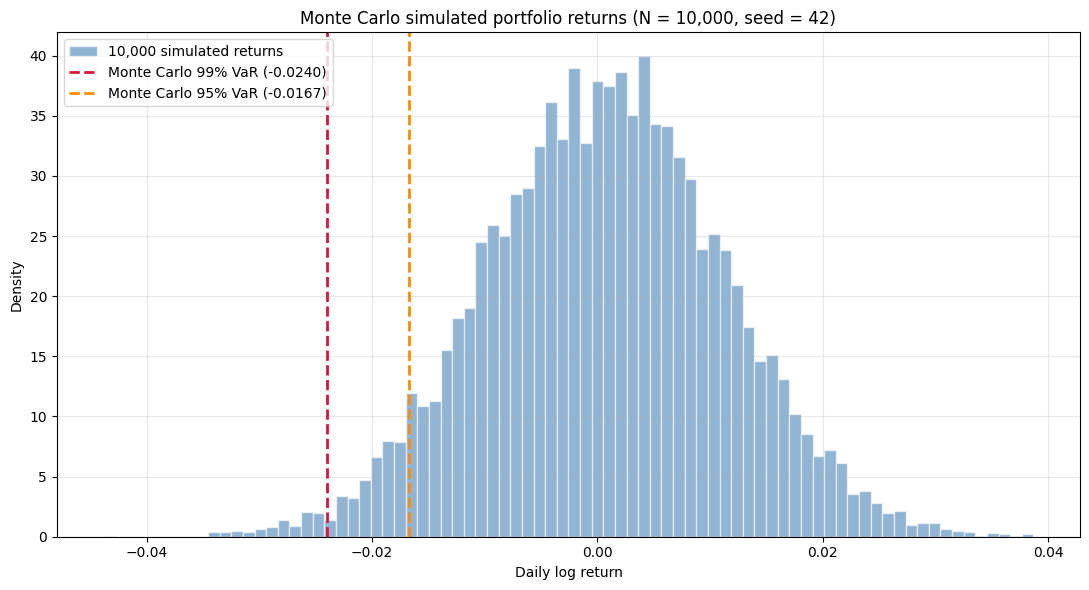

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(sim_portfolio_returns, bins=80, density=True, alpha=0.6,
        color="steelblue", edgecolor="white", label=f"{N_SIMULATIONS:,} simulated returns")
ax.axvline(mc_var_99, color="crimson", linestyle="--", linewidth=2,
           label=f"Monte Carlo 99% VaR ({mc_var_99:.4f})")
ax.axvline(mc_var_95, color="darkorange", linestyle="--", linewidth=2,
           label=f"Monte Carlo 95% VaR ({mc_var_95:.4f})")
ax.set_title(f"Monte Carlo simulated portfolio returns (N = {N_SIMULATIONS:,}, seed = {SEED})")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/monte_carlo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Convergence check — how many paths is enough?

The natural interview question. Run the simulation at 1k, 5k, 10k, 25k, and 50k paths and plot how the 99% VaR estimate stabilises. For each path count, repeat 30 times with different seeds to estimate the *standard error* of the VaR estimate at that size — error bars matter more than the point estimate.

In [7]:
path_counts = [1_000, 5_000, 10_000, 25_000, 50_000]
n_repeats = 30

# Pre-compute Cholesky and drift once (avoids redoing in inner loop)
L_fixed   = L
drift     = daily_mean

records = []
for n_paths in path_counts:
    vars_99 = []
    for rep in range(n_repeats):
        np.random.seed(SEED + 1 + rep)
        Z_inner   = np.random.standard_normal((n_paths, n_assets))
        sim       = (Z_inner @ L_fixed.T + drift) @ weights
        vars_99.append(np.percentile(sim, 1))
    arr = np.array(vars_99)
    records.append({
        "n_paths": n_paths,
        "mean_99_VaR":  arr.mean(),
        "std_99_VaR":   arr.std(),
        "min_99_VaR":   arr.min(),
        "max_99_VaR":   arr.max(),
    })

convergence = pd.DataFrame(records)
print(convergence.to_string(index=False))

 n_paths  mean_99_VaR  std_99_VaR  min_99_VaR  max_99_VaR
    1000    -0.023546    0.001331   -0.025916   -0.020810
    5000    -0.023787    0.000571   -0.025020   -0.022746
   10000    -0.023793    0.000320   -0.024323   -0.023025
   25000    -0.023959    0.000258   -0.024495   -0.023405
   50000    -0.024000    0.000142   -0.024386   -0.023680


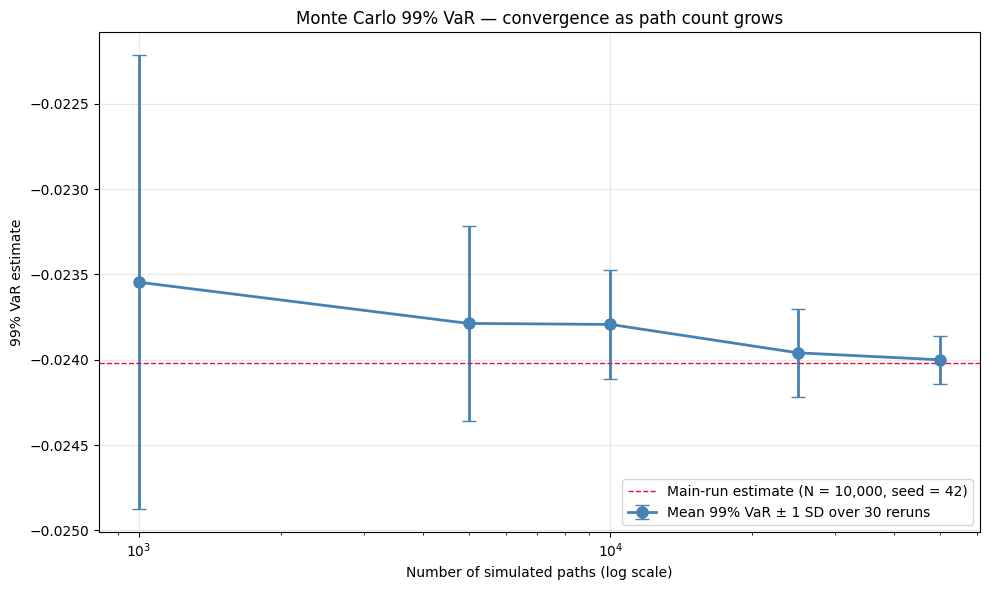

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    convergence["n_paths"], convergence["mean_99_VaR"],
    yerr=convergence["std_99_VaR"],
    fmt="o-", color="steelblue", capsize=5, linewidth=2, markersize=8,
    label=f"Mean 99% VaR ± 1 SD over {n_repeats} reruns",
)
ax.axhline(mc_var_99, linestyle="--", color="crimson", linewidth=1,
           label=f"Main-run estimate (N = {N_SIMULATIONS:,}, seed = {SEED})")
ax.set_xscale("log")
ax.set_xlabel("Number of simulated paths (log scale)")
ax.set_ylabel("99% VaR estimate")
ax.set_title("Monte Carlo 99% VaR — convergence as path count grows")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the convergence plot.** The standard deviation across reruns shrinks rapidly — by 10,000 paths, the standard error of the 99% VaR estimate is small enough that the point estimate is stable to roughly the third decimal place. 50,000 paths shrinks the error further but with diminishing returns; the wall-clock cost grows linearly while the precision improvement scales as √N.

**The takeaway for the interview:** 10,000 paths is the conventional choice because it sits at the inflection point where additional paths give marginal precision gains. Below 5,000 you can see noticeable run-to-run variation in the tail; above 25,000 you're spending compute on decimal places that don't change the business decision.